In [27]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Import the data

In [13]:
data_dir = Path("../data")
silver_dir = data_dir / "silver"

In [16]:
labeled_train_data = pd.read_csv(silver_dir / "train_data.csv")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    labeled_train_data[col] = le.fit_transform(labeled_train_data[col])

train_data = labeled_train_data.drop(columns=['attack_type'])

display(train_data.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,22,9,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0,1,22,9,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


In [17]:
labeled_test_data = pd.read_csv(silver_dir / "test_data.csv")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    labeled_test_data[col] = le.fit_transform(labeled_test_data[col])

test_data = labeled_test_data.drop(columns=['attack_type'])

display(train_data.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,22,9,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0,1,22,9,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0,1,22,9,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0,1,22,9,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0,1,22,9,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


### Data transoformation
To speed up model training time and just to make it possible on local PC, we decided to use PCA reduction with standard value for required variance of 95%. The Standard Scaling **must** be used, since some features (for instance `dst_bytes`, `dst_host_name_src_port_rate` and `service`) have differnt scales of values -- `10^3` vs `10^-21` vs `10^1`

In [22]:
scaler = StandardScaler()
pca = PCA(n_components=0.95)

In [23]:
X_train = scaler.fit_transform(train_data)
X_train_reduced = pca.fit_transform(X_train)
display(X_train_reduced)

array([[-0.51308355,  0.97771224,  4.06736601, ..., -1.29026035,
        -0.1567914 ,  0.76453393],
       [-0.51506643,  0.95953429,  4.03533344, ..., -1.26833813,
        -0.1614664 ,  0.73031855],
       [-0.49538589,  0.94023223,  3.99190704, ..., -1.23740637,
        -0.16073011,  0.69062944],
       ...,
       [-0.10393274,  1.04939744,  4.6246435 , ..., -0.68288203,
        -0.15111561,  0.82329753],
       [ 0.07796747,  1.23358962,  4.62767484, ..., -0.64638014,
        -0.15627859,  0.70891244],
       [ 0.197038  ,  1.27726331,  4.61227102, ..., -0.88716207,
        -0.14761184,  0.78729659]], shape=(494021, 20))

In [24]:
X_test = scaler.transform(test_data)
X_test_reduced = pca.transform(X_test)
display(X_test_reduced)

array([[-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       [-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       [-0.75979208,  0.31208897,  2.02743934, ..., -0.12350554,
        -0.04700267, -1.46459604],
       ...,
       [-0.7378908 ,  0.30522481,  2.02291078, ..., -0.11898853,
        -0.04841877, -1.42288297],
       [-0.7338201 ,  0.30388777,  2.01738269, ..., -0.1178944 ,
        -0.04839773, -1.42129092],
       [-0.7378908 ,  0.30522481,  2.02291078, ..., -0.11898853,
        -0.04841877, -1.42288297]], shape=(311029, 20))

### Model training
Using `MinibatchKMeans` to calcualate Elbow chart and Silhouette Score and find optimal number of clausters. Then train KMeans++ model. 

In [38]:
inertia = []
scores = []

K = range(2, 11)

for k in K:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++',
        n_init=10,
        batch_size=4096
    )
    model.fit(X_train_reduced)
    inertia.append(model.inertia_)
    labels = model.predict(X_test_reduced)
    score = silhouette_score(X=X_test_reduced, labels=labels, sample_size=20_000, random_state=42)
    scores.append(score)

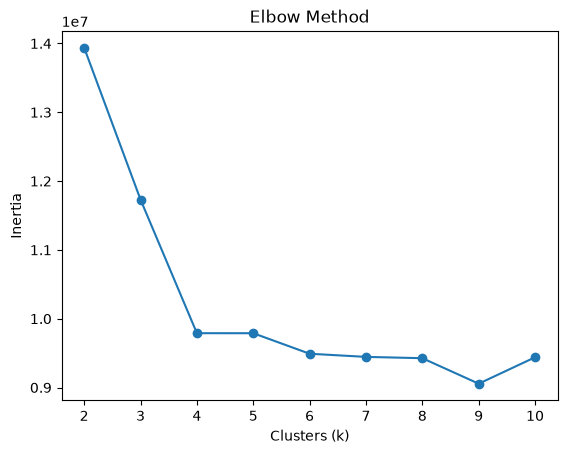

In [39]:
plt.plot(K, inertia, marker='o')
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

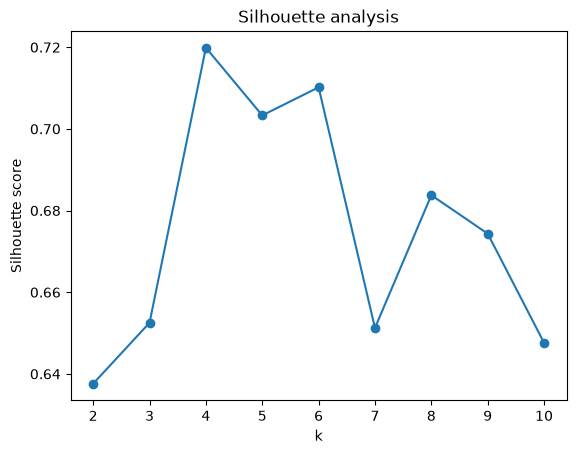

In [40]:
plt.plot(K, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette analysis")
plt.show()

#### Traing of the KMeans with oprimal number of clusters (k=4)
The number of clusters perfectly alligns with number of atack types:
> Attacks fall into four main categories:
> - `DOS`: denial-of-service, e.g. syn flood;
> - `R2L`: unauthorized access from a remote machine, e.g. guessing password;
> - `U2R`:  unauthorized access to local superuser (root) privileges, e.g., various `buffer overflow` attacks;
> - `probing`: surveillance and other probing, e.g., port scanning.
Sioulette Score [-1;1] and Davies-Bouldin Index [0; +inf] have values close to the optimal, which suggests that the model is good yet not overfit. High Calinski-Harabasz Index value supports this conclusion and indicates that the clusters are dense and have good separation

In [37]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

model = KMeans(
        n_clusters=4,
        random_state=42,
        init='k-means++',
        n_init=10,
    )
model.fit(X_train_reduced)

labels_pred = model.predict(X_test_reduced)
score = silhouette_score(X=X_test_reduced, labels=labels, sample_size=20_000, random_state=42)
print("Silhouette Score:   ", silhouette_score(X_test_reduced, labels_pred))
print("Davies-Bouldin:     ", davies_bouldin_score(X_test_reduced, labels_pred))
print("Calinski-Harabasz:  ", calinski_harabasz_score(X_test_reduced, labels_pred))

Silhouette Score:    0.7152235620933313
Davies-Bouldin:      0.678782707232298
Calinski-Harabasz:   67507.11447060577


In [ ]:
dbscan_model = DBSCAN(algorithm='ball_tree')
dbscan_result = dbscan_model.fit_predict(X_train_reduced)
dbscan_clusters = np.unique(dbscan_result)
dbscan_result.value_counts()

/home/nazar/projects/network-anomaly-prediction/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
